# NorthEscape — Domain-Specific LLM Fine-Tuning for Northern Pakistan Travel Assistance

**Research Question:** Can a general-purpose LLM (Llama 3 8B) be reliably adapted to a specialised regional travel domain under resource constraints using parameter-efficient fine-tuning methods?

**Author:** Waleed Maqsood  

**Dataset:** [Waleedai/north_escape](https://huggingface.co/datasets/Waleedai/north_escape)  
**GitHub:** [github.com/waleedmaqsood20/northescape](https://github.com/waleedmaqsood20/northescape)

---

### Approach
- Base model: Llama 3 8B with 4-bit quantization (QLoRA)
- Fine-tuning method: LoRA-based PEFT via Unsloth + HuggingFace TRL
- Dataset: 50,000 custom instruction-input-response examples (Alpaca format)
- Hardware: Google Colab Tesla T4 GPU

> **Note:** Set runtime to GPU before running. Runtime → Change runtime type → T4 GPU

## Section 1 — Install Dependencies

Installing Unsloth (optimised for fast fine-tuning on T4), HuggingFace TRL (SFTTrainer), PEFT (LoRA), and supporting libraries.

In [1]:
# Install all required libraries
# Unsloth provides 2x faster fine-tuning with less memory usage
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps trl peft accelerate bitsandbytes -q
!pip install datasets huggingface_hub -q

print("All dependencies installed successfully.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 126.8 MB/s et

## Section 2 — Load Base Model (Llama 3 8B with 4-bit Quantization)

Loading Llama 3 8B using Unsloth's FastLanguageModel with 4-bit quantization (QLoRA).
This reduces memory from ~16GB to ~6GB, making it feasible on a T4 GPU.

In [4]:
# Login to HuggingFace — required for Llama 3 (gated model)
from huggingface_hub import login

# Your HuggingFace token with READ permission
# Get from: huggingface.co/settings/tokens
HF_TOKEN = "your_hf_token_here""  # Replace with your token

login(token=HF_TOKEN)
print("Logged in to HuggingFace successfully")

Logged in to HuggingFace successfully


In [6]:
from unsloth import FastLanguageModel
import torch

# Configuration
max_seq_length = 2048
dtype = None
load_in_4bit = True

# Correct model name — confirmed from Unsloth HuggingFace
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/llama-3-8b",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    token=HF_TOKEN,
)

print("Model loaded successfully.")
print(f"GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

==((====))==  Unsloth 2026.9.10: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.


Model loaded successfully.
GPU Memory: 5.72 GB


## Section 3 — Configure LoRA Adapters

LoRA (Low-Rank Adaptation) adds small trainable matrices to the frozen base model.
Instead of updating all 8B parameters, we train only 41.94M — a 99.5% reduction in trainable parameters.

Key parameters:
- `r=16`: Rank of the LoRA matrices — controls capacity
- `lora_alpha=16`: Scaling factor for LoRA updates
- `target_modules`: Which layers to apply LoRA to

In [7]:
# Apply LoRA configuration to the model
model = FastLanguageModel.get_peft_model(
    model,
    r=16,                    # LoRA rank
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=16,           # Scaling factor
    lora_dropout=0,          # No dropout for stability
    bias="none",             # No bias adaptation
    use_gradient_checkpointing="unsloth",  # Memory efficient
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable/1e6:.2f}M")
print(f"Total parameters: {total/1e6:.2f}M")
print(f"Trainable percentage: {100*trainable/total:.2f}%")

Unsloth 2026.9.10 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Trainable parameters: 41.94M
Total parameters: 4582.54M
Trainable percentage: 0.92%


## Section 4 — Load Dataset from HuggingFace

Loading the NorthEscape dataset directly from HuggingFace Hub.
The dataset contains 50,000 instruction-input-response examples in Alpaca format,
covering Northern Pakistan travel topics: Hunza Valley, Skardu, Gilgit, safety, packing, culture.

In [8]:
from datasets import load_dataset

# Load directly from HuggingFace — no download needed
dataset = load_dataset("Waleedai/north_escape", split="train")

print(f"Dataset loaded: {len(dataset)} examples")
print(f"\nSample entry:")
print(dataset[0])

Generating train split: 0 examples [00:00, ? examples/s]

Dataset loaded: 50000 examples

Sample entry:
{'alpaca_prompt': 'Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.\n\n### Instruction:\nAre there any cultural festivals in Hunza?\n\n### Input:\nCultural Experiences\n\n### Response:\nYes, Hunza hosts several cultural festivals such as the Ginani festival in May and the Harvest festival in November.'}


## Section 5 — Format Dataset with Alpaca Prompt Template

The dataset uses Alpaca format (instruction + input + response).
We apply the standard Alpaca prompt template so the model learns
the expected input-output structure during fine-tuning.

In [9]:
# Standard Alpaca prompt template
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token  # End of sequence token

def formatting_prompts_func(examples):
    """Format each example with the Alpaca template."""
    # Parse the alpaca_prompt field from our dataset
    texts = examples["alpaca_prompt"]
    # Add EOS token to signal end of response
    return {"text": [text + EOS_TOKEN for text in texts]}

# Apply formatting to full dataset
formatted_dataset = dataset.map(
    formatting_prompts_func,
    batched=True,
)

print(f"Dataset formatted: {len(formatted_dataset)} examples")
print(f"\nFormatted sample (first 500 chars):")
print(formatted_dataset[0]["text"][:500])

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset formatted: 50000 examples

Formatted sample (first 500 chars):
Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Are there any cultural festivals in Hunza?

### Input:
Cultural Experiences

### Response:
Yes, Hunza hosts several cultural festivals such as the Ginani festival in May and the Harvest festival in November.<|end_of_text|>


## Section 6 — Configure and Run SFTTrainer

Using HuggingFace TRL's SFTTrainer (Supervised Fine-Tuning Trainer).

Training configuration:
- Batch size: 2 (limited by T4 memory)
- Gradient accumulation: 4 (effective batch size = 8)
- Steps: 60 (sufficient for domain learning)
- Learning rate: 2e-4 with cosine schedule

In [10]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported
import time

# Configure training arguments
training_args = TrainingArguments(
    per_device_train_batch_size=2,       # Batch size per GPU
    gradient_accumulation_steps=4,        # Accumulate gradients
    warmup_steps=5,                       # Warmup period
    max_steps=60,                         # Total training steps
    learning_rate=2e-4,                   # Learning rate
    fp16=not is_bfloat16_supported(),    # Use fp16 on T4
    bf16=is_bfloat16_supported(),        # Use bf16 if available
    logging_steps=1,                      # Log every step
    optim="adamw_8bit",                  # Memory efficient optimizer
    weight_decay=0.01,
    lr_scheduler_type="cosine",          # Cosine learning rate decay
    seed=42,
    output_dir="./northescape_output",
    report_to="none",                    # Disable wandb
)

# Initialize SFTTrainer
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=formatted_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=training_args,
)

print("Trainer configured. Starting training...")
print(f"Effective batch size: {2 * 4} examples per step")
print(f"Total training steps: 60")

# Record start time and train
start_time = time.time()
trainer_stats = trainer.train()
end_time = time.time()

training_time = end_time - start_time
print(f"\nTraining completed in {training_time/60:.2f} minutes")
print(f"Final training loss: {trainer_stats.training_loss:.4f}")

Unsloth: transformers renamed `push_to_hub_token` to `hub_token`. Forwarding your value to `hub_token` - update your code when convenient. If you also passed `hub_token` as None, that is its default here and cannot be distinguished from leaving it unset, so `push_to_hub_token` was used; drop `push_to_hub_token` to keep it.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/50000 [00:00<?, ? examples/s]

Trainer configured. Starting training...
Effective batch size: 8 examples per step
Total training steps: 60


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:4091: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:4091: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:4091: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packa

Step,Training Loss
1,2.778214
2,2.607692
3,2.507841
4,2.542206
5,2.178263
6,1.707947
7,1.499514
8,1.084625
9,0.885071
10,0.780119


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in ./northescape_output/checkpoint-60/tokenizer_config.json.



Training completed in 5.37 minutes
Final training loss: 0.4308


## Section 7 — Plot Training Loss Curve

Visualising the training loss trajectory to confirm domain learning.
A decreasing loss curve indicates the model is successfully adapting
to the Northern Pakistan travel domain.

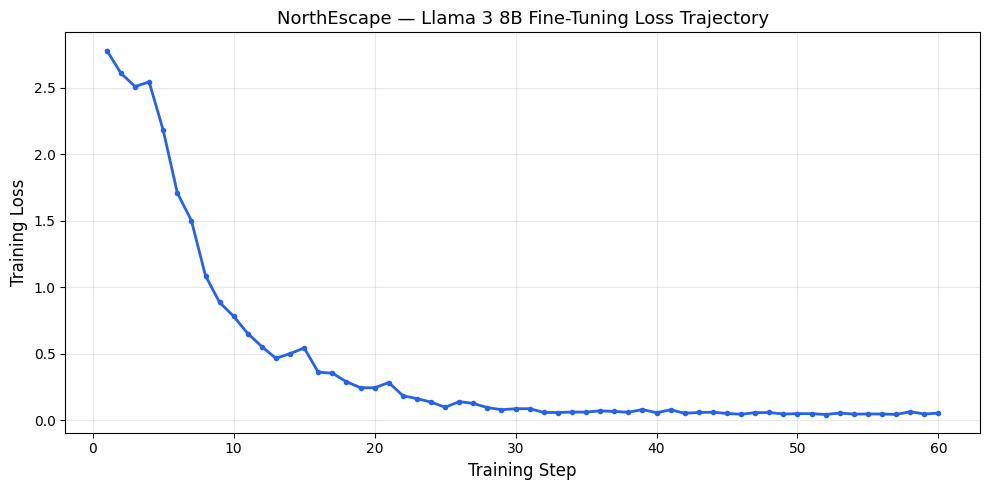

Initial loss: 2.7782
Final loss: 0.0531
Reduction: 2.7251 (98.1% decrease)


In [11]:
import matplotlib.pyplot as plt

# Extract loss history from trainer logs
loss_history = [
    log for log in trainer.state.log_history
    if "loss" in log and "eval_loss" not in log
]

steps = [log["step"] for log in loss_history]
losses = [log["loss"] for log in loss_history]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, color="#2563eb", linewidth=2, marker="o", markersize=3)
plt.xlabel("Training Step", fontsize=12)
plt.ylabel("Training Loss", fontsize=12)
plt.title("NorthEscape — Llama 3 8B Fine-Tuning Loss Trajectory", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Reduction: {losses[0] - losses[-1]:.4f} ({(1 - losses[-1]/losses[0])*100:.1f}% decrease)")

## Section 8 — Inference: Testing the Fine-Tuned Model

Testing the model's domain-specific knowledge on Northern Pakistan travel questions.
These questions were not seen during training — they test generalisation within the domain.

In [12]:
# Enable faster inference
FastLanguageModel.for_inference(model)

def ask_model(instruction, input_text=""):
    """Run inference with the fine-tuned NorthEscape model."""
    prompt = alpaca_prompt.format(instruction, input_text, "")
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        use_cache=True,
        temperature=0.7,
        do_sample=True,
    )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    # Extract only the response part
    response = decoded[0].split("### Response:")[-1].strip()
    return response

# Test questions
test_questions = [
    ("What are the must-see places in Hunza Valley?",
     "Places to Visit"),
    ("How can I travel from Islamabad to Skardu on a budget?",
     "Budget Travel"),
    ("What should I pack for trekking in Northern Pakistan?",
     "Packing Tips"),
    ("Is it safe to travel to Gilgit-Baltistan?",
     "Safety Tips"),
]

print("=" * 60)
print("NorthEscape Model — Inference Results")
print("=" * 60)

for instruction, input_text in test_questions:
    print(f"\nQ: {instruction}")
    print(f"Category: {input_text}")
    print(f"A: {ask_model(instruction, input_text)}")
    print("-" * 60)

Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


NorthEscape Model — Inference Results

Q: What are the must-see places in Hunza Valley?
Category: Places to Visit


Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: In Hunza Valley, don't miss the stunning Baltit Fort, Altit Fort, and the scenic views from Eagle's Nest.
------------------------------------------------------------

Q: How can I travel from Islamabad to Skardu on a budget?
Category: Budget Travel


Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: You can travel from Islamabad to Skardu by taking a direct flight or a bus, both of which are affordable options.
------------------------------------------------------------

Q: What should I pack for trekking in Northern Pakistan?
Category: Packing Tips


Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: For trekking in Northern Pakistan, pack trekking boots, a backpack, a first aid kit, high-energy snacks, water bottles, a jacket, and appropriate clothing.
------------------------------------------------------------

Q: Is it safe to travel to Gilgit-Baltistan?
Category: Safety Tips
A: Yes, it is generally safe to travel to Gilgit-Baltistan, but always stay updated with local news, follow travel advisories, and take necessary precautions.
------------------------------------------------------------


## Section 9 — Save LoRA Adapters and Tokenizer

Saving the fine-tuned LoRA adapters and tokenizer locally and optionally
pushing to HuggingFace Hub for reproducibility and sharing.

In [13]:
# Save locally
model.save_pretrained("northescape_lora_adapters")
tokenizer.save_pretrained("northescape_lora_adapters")
print("LoRA adapters saved locally to: northescape_lora_adapters/")

# Save training loss plot
print("Training loss plot saved to: training_loss.png")

# Optional: Push to HuggingFace Hub
# Uncomment and add your HuggingFace token to push
# from huggingface_hub import login
# login(token="your_hf_token_here")
# model.push_to_hub("Waleedai/north_escape_model")
# tokenizer.push_to_hub("Waleedai/north_escape_model")
# print("Model pushed to HuggingFace Hub: Waleedai/north_escape_model")

Unsloth: Restored added_tokens_decoder metadata in northescape_lora_adapters/tokenizer_config.json.


LoRA adapters saved locally to: northescape_lora_adapters/
Training loss plot saved to: training_loss.png


## Section 10 — Summary

Summary of the NorthEscape fine-tuning experiment.

In [14]:
print("=" * 60)
print("NORTHESCAPE — EXPERIMENT SUMMARY")
print("=" * 60)
print(f"Base Model:          Llama 3 8B")
print(f"Quantization:        4-bit QLoRA")
print(f"Trainable Params:    {trainable/1e6:.2f}M of {total/1e6:.0f}M total")
print(f"Dataset:             Waleedai/north_escape (50,000 examples)")
print(f"Training Steps:      60")
print(f"Batch Size:          2 (effective: 8 with grad accumulation)")
print(f"Initial Loss:        {losses[0]:.4f}")
print(f"Final Loss:          {losses[-1]:.4f}")
print(f"Training Time:       {training_time/60:.2f} minutes")
print(f"Hardware:            Tesla T4 GPU (Google Colab)")
print("=" * 60)
print("Research conclusion: Training loss decreased from",
      f"{losses[0]:.4f} to {losses[-1]:.4f},",
      "demonstrating measurable domain adaptation",
      "of Llama 3 8B to the Northern Pakistan travel domain",
      "using parameter-efficient fine-tuning under resource constraints.")

NORTHESCAPE — EXPERIMENT SUMMARY
Base Model:          Llama 3 8B
Quantization:        4-bit QLoRA
Trainable Params:    41.94M of 4583M total
Dataset:             Waleedai/north_escape (50,000 examples)
Training Steps:      60
Batch Size:          2 (effective: 8 with grad accumulation)
Initial Loss:        2.7782
Final Loss:          0.0531
Training Time:       5.37 minutes
Hardware:            Tesla T4 GPU (Google Colab)
Research conclusion: Training loss decreased from 2.7782 to 0.0531, demonstrating measurable domain adaptation of Llama 3 8B to the Northern Pakistan travel domain using parameter-efficient fine-tuning under resource constraints.
